# Cross Validation of NMF

In [1]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import os

sns.set("talk", "ticks", palette='colorblind')

## Write the Nonnegative Matrix Factorization Code that can handle missing data

In [2]:
from nnls import nnlsm_blockpivot as nnlstsq

def censored_nnlstsq(A, B, M):
    """Solves nonnegative least-squares problem with missing data in B
    Args
    ----
    A (ndarray) : m x r matrix
    B (ndarray) : m x n matrix
    M (ndarray) : m x n binary matrix (zeros indicate missing values)

    Returns
    -------
    X (ndarray) : nonnegative r x n matrix that minimizes norm(M*(AX - B))
    """
    if A.ndim == 1:
        A = A[:, None]

    rhs = np.dot(A.T, M * B).T[:, :, None] # n x r x 1 tensor
    T = np.matmul(A.T[None,:,:], M.T[:,:,None] * A[None,:,:]) # n x r x r tensor
    X = np.empty((B.shape[1], A.shape[1]))

    for n in range(B.shape[1]):
        X[n] = nnlstsq(T[n], rhs[n], is_input_prod=True)[0].T

    return X.T


def cv_nmf(data, rank, M=None, p_holdout=0.3, tol=0.001, verbose=False, max_iter=50):
    """Perform cross-validation for NMF using a speckled holdout pattern.

    This code was adapted from Alex Williams at Stanford (https://bit.ly/2KDqKoW).

    Args
    ----
    data (ndarray)    : m x n matrix (original data/time-series)
    rank (int)        : the desired output rank (i.e. number of factors)
    M (ndarray)       : m x n binary matrix where zeroes indicate missing/heldout values
    p_holdout (float) : all random data under this value will be set to False
    tol (float)       : the tolerance for convergence - the solution has converged when
                        the MSE of subsequent iterations are less than this number
    verbose (bool)    : if True, print out debugging information
    max_itr (int)     : the maximum number of iterations for convergence

    Returns
    -------
    U (ndarray)       :
    Vt (ndarray)      :
    train_err (float) :
    test_err (float)  :
    converged (bool)  :

    """

    # create the masking matrix to decide which values to "hold out"
    if M is None:
        M = np.random.rand(*data.shape) > p_holdout

        # check to make sure there are enough values in each row to avoid singular matrix issues
        if M.sum(axis=0).any() < rank:
            for i in range(M.shape[0]):
                if M[i].sum() < rank:
                    M[i, :] = [True]*M.shape[1]

    # initialize U randomly
    U = np.random.rand(data.shape[0], rank)

    # init the mean err
    mse = 100

    # fit NMF
    for itr in range(max_iter):
        Vt = censored_nnlstsq(U, data, M)
        U = censored_nnlstsq(Vt.T, data.T, M.T).T

        # calculate the current iterations mean squared error
        tmp_mse = np.mean((np.dot(U, Vt) - data)**2)
        diff = mse - tmp_mse

        # break out of the loop if converged
        if abs(diff) <= tol:
            converged = True
            break
        else:
            mse = tmp_mse
            converged = False

    if verbose:
        train_pct = 100 * M.sum() / M.size
        print ("\tIter {} = {:.5f}".format(itr+1, diff))
        print ("\tTrain/Test = {:.2f}/{:.2f}".format(train_pct, 100-train_pct))

    # return the result and the train/test error
    resid = np.dot(U, Vt) - data
    train_err = np.mean(resid[M]**2)
    test_err = np.mean(resid[~M]**2)

    return U, Vt, train_err, test_err, converged

In [3]:
import numpy as np
import scipy.linalg as sla
import numpy.linalg as nla

# ---------- NNLS block-pivot solver ----------
def nnlsm_blockpivot(A, B, is_input_prod=False, init=None):
    """ Nonnegativity-constrained least squares with block principal pivoting. """
    if is_input_prod:
        AtA = A
        AtB = B
    else:
        AtA = A.T.dot(A)
        AtB = A.T.dot(B)

    n, k = AtB.shape
    X = np.zeros((n, k))
    Y = -AtB if init is None else AtA.dot(X) - AtB
    PassSet = np.zeros((n, k), dtype=bool)
    MAX_ITER = n * 5
    big_iter = 0
    success = True

    while True:
        not_opt_set = np.logical_and(Y < 0, ~PassSet)
        infea_set = np.logical_and(X < 0, PassSet)
        not_good = np.sum(not_opt_set, axis=0) + np.sum(infea_set, axis=0)
        not_opt_cols = (not_good > 0).nonzero()[0]
        if not_opt_cols.size == 0:
            break

        big_iter += 1
        if big_iter > MAX_ITER:
            success = False
            break

        # Solve each non-optimal column
        for j in not_opt_cols:
            cols = np.arange(n)
            if np.any(PassSet[:, j]):
                cols = cols[PassSet[:, j]]
            if cols.size > 0:
                x_new = nla.solve(AtA[np.ix_(cols, cols)], AtB[cols, j])
                X[cols, j] = np.maximum(x_new, 0)
        Y = AtA.dot(X) - AtB

    return X, (success, Y, 0, 0, 0)

# Assign to variable used in censored_nnlstsq
nnlstsq = nnlsm_blockpivot


In [4]:
def censored_nnlstsq(A, B, M):
    """
    Solves min ||M*(AX - B)|| subject to X >= 0
    A : m x r matrix
    B : m x n matrix
    M : mask of same shape as B, 1=observed, 0=missing
    """
    B_masked = M * B
    r = A.shape[1]
    n = B.shape[1]
    X = np.zeros((r, n))

    for j in range(n):
        b_col = B_masked[:, j].reshape(-1, 1)
        A_masked = A * M[:, j][:, np.newaxis]
        x_col, _ = nnlstsq(A_masked, b_col)
        X[:, j] = x_col.flatten()

    return X


In [5]:
# Example data
m, r, n = 5, 3, 4
A = np.random.rand(m, r)
B = np.random.rand(m, n)
M = (np.random.rand(m, n) > 0.2).astype(float)  # 80% observed, 20% missing

# Solve censored NNLS
X = censored_nnlstsq(A, B, M)
print("Solution X:\n", X)

Solution X:
 [[0.         0.96721361 1.7028981  0.        ]
 [2.70051294 0.09550076 0.         1.08830626]
 [0.         0.         0.10470682 1.16513407]]


In [6]:
# Make sure nnlsm_blockpivot is already defined in your notebook
# Assign it to nnlstsq
nnlstsq = nnlsm_blockpivot

def censored_nnlstsq(A, B, M):
    """Solves nonnegative least-squares problem with missing data in B
    Args
    ----
    A (ndarray) : m x r matrix
    B (ndarray) : m x n matrix
    M (ndarray) : m x n binary matrix (zeros indicate missing values)

    Returns
    -------
    X (ndarray) : nonnegative r x n matrix that minimizes norm(M*(AX - B))
    """
    if A.ndim == 1:
        A = A[:, None]

    rhs = np.dot(A.T, M * B).T[:, :, None] # n x r x 1 tensor
    T = np.matmul(A.T[None,:,:], M.T[:,:,None] * A[None,:,:]) # n x r x r tensor
    X = np.empty((B.shape[1], A.shape[1]))

    for n_idx in range(B.shape[1]):
        X[n_idx] = nnlstsq(T[n_idx], rhs[n_idx], is_input_prod=True)[0].T

    return X.T

def cv_nmf(data, rank, M=None, p_holdout=0.3, tol=0.001, verbose=False, max_iter=50):
    """Perform cross-validation for NMF using a speckled holdout pattern.

    Args
    ----
    data (ndarray)    : m x n matrix (original data/time-series)
    rank (int)        : the desired output rank (i.e. number of factors)
    M (ndarray)       : m x n binary matrix where zeroes indicate missing/heldout values
    p_holdout (float) : all random data under this value will be set to False
    tol (float)       : the tolerance for convergence
    verbose (bool)    : if True, print debugging information
    max_iter (int)    : maximum number of iterations

    Returns
    -------
    U (ndarray), Vt (ndarray), train_err (float), test_err (float), converged (bool)
    """

    # create the masking matrix to decide which values to "hold out"
    if M is None:
        M = np.random.rand(*data.shape) > p_holdout

        # check to make sure there are enough values in each row to avoid singular matrix issues
        for i in range(M.shape[0]):
            if M[i].sum() < rank:
                M[i, :] = True

    # initialize U randomly
    U = np.random.rand(data.shape[0], rank)

    # init the mean err
    mse = 100

    # fit NMF
    for itr in range(max_iter):
        Vt = censored_nnlstsq(U, data, M)
        U = censored_nnlstsq(Vt.T, data.T, M.T).T

        # calculate the current iteration's mean squared error
        tmp_mse = np.mean((np.dot(U, Vt) - data)**2)
        diff = mse - tmp_mse

        # break out of the loop if converged
        if abs(diff) <= tol:
            converged = True
            break
        else:
            mse = tmp_mse
            converged = False

    if verbose:
        train_pct = 100 * M.sum() / M.size
        print ("\tIter {} = {:.5f}".format(itr+1, diff))
        print ("\tTrain/Test = {:.2f}/{:.2f}".format(train_pct, 100-train_pct))

    # return the result and the train/test error
    resid = np.dot(U, Vt) - data
    train_err = np.mean(resid[M]**2)
    test_err = np.mean(resid[~M]**2)

    return U, Vt, train_err, test_err, converged


## Let's try an example...

In [7]:
N, R = 150, 4

noise = 0.8
replicates = 10

ranks = np.arange(1, 8)

# initialize the problem
U = np.random.rand(N, R) # (150, 4)
Vt = np.random.rand(R, N) # (4, 150)

# create the data by making it noisy
data = np.dot(U, Vt) + noise * np.random.rand(N, N) # (150, 150)

frame = pd.DataFrame()

# fit the models
for rnk, _ in itertools.product(ranks, range(replicates)):
    tr, te, converged = cv_nmf(data, rnk, verbose=False)[2:]

    if converged:

        new_rows = pd.DataFrame([
            {"Rank": rnk, "MSE": tr, "Group": "Train"},
            {"Rank": rnk, "MSE": te, "Group": "Test"},])

        frame = pd.concat([frame, new_rows], ignore_index=True)

    else:
        print ("there was a convergence issue: {}".format(rnk))

frame["Rank"] = frame["Rank"].astype(np.int32)

# prepare for plotting
groups = frame.groupby(["Group", "Rank"]).describe(percentiles=[0.05, 0.95])

In [8]:
groups

MSE                                                              \
           count      mean       std       min        5%       50%       95%   
Group Rank                                                                     
Test  1     10.0  0.075890  0.001071  0.074821  0.074839  0.075647  0.077446   
      2     10.0  0.070457  0.000660  0.069662  0.069675  0.070501  0.071463   
      3     10.0  0.065437  0.000962  0.063782  0.064092  0.065583  0.066519   
      4     10.0  0.060404  0.002645  0.058402  0.058689  0.059866  0.064414   
      5     10.0  0.060999  0.000815  0.059525  0.059723  0.061124  0.061890   
      6     10.0  0.064025  0.000654  0.062774  0.063132  0.063898  0.064755   
      7     10.0  0.065969  0.001006  0.064382  0.064519  0.066081  0.067299   
Train 1     10.0  0.073154  0.000439  0.072355  0.072537  0.073252  0.073593   
      2     10.0  0.065611  0.000391  0.064809  0.064969  0.065705  0.066009   
      3     10.0  0.058081  0.000643  0.057247  0.057297  0.058135  0.059036   
      4     10.0  0.051407  0.001748  0.050340  0.050351  0.050745  0.054216   
      5     10.0  0.049378  0.000436  0.048695  0.048811  0.049486  0.049956   
      6     10.0  0.048106  0.000291  0.047667  0.047693  0.048093  0.048480   
      7     10.0  0.046998  0.000441  0.046500  0.046527  0.046996  0.047655   

                      
                 max  
Group Rank            
Test  1     0.078037  
      2     0.071873  
      3     0.066623  
      4     0.067707  
      5     0.061966  
      6     0.064805  
      7     0.067459  
Train 1     0.073603  
      2     0.066041  
      3     0.059294  
      4     0.056162  
      5     0.049982  
      6     0.048539  
      7     0.048034

## Plot the results

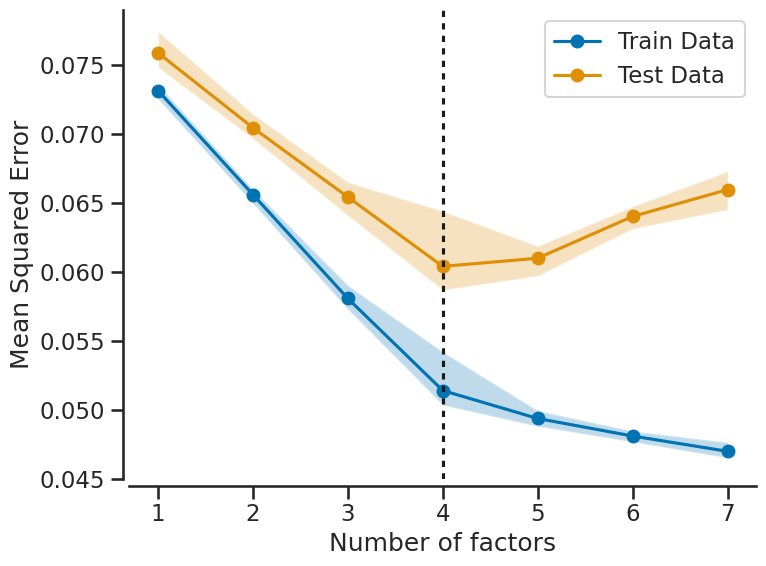

In [9]:
fig, ax = plt.subplots(1, figsize=(8, 6))

ax.plot(groups["MSE"]["mean"]["Train"], 'o-', label="Train Data")
ax.plot(groups["MSE"]["mean"]["Test"], 'o-', label="Test Data")

ax.fill_between(groups["MSE"]["5%"]["Train"].index, groups["MSE"]["5%"]["Train"],
                groups["MSE"]["95%"]["Train"], alpha=0.25)
ax.fill_between(groups["MSE"]["5%"]["Test"].index, groups["MSE"]["5%"]["Test"],
                groups["MSE"]["95%"]["Test"], alpha=0.25)

inflection = (groups["MSE"]["mean"]["Test"] > groups["MSE"]["mean"]["Test"].shift()).idxmax() - 1

ax.axvline(inflection, color='k', dashes=[2, 2])

sns.despine(offset=5)
ax.set_ylabel("Mean Squared Error")
ax.set_xlabel("Number of factors")
ax.legend()
plt.tight_layout()

## Trying on Our Data

In [10]:
# Make sure nnlsm_blockpivot is already defined in your notebook
nnlstsq = nnlsm_blockpivot

def censored_nnlstsq2(A, B, M):
    """Solves nonnegative least-squares problem with missing data in B
    Args
    ----
    A (ndarray) : m x r matrix
    B (ndarray) : m x n matrix
    M (ndarray) : m x n binary matrix (zeros indicate missing values)

    Returns
    -------
    X (ndarray) : nonnegative r x n matrix that minimizes norm(M*(AX - B))
    """
    if A.ndim == 1:
        A = A[:, None]

    rhs = np.dot(A.T, M * B).T[:, :, None]  # n x r x 1 tensor
    T = np.matmul(A.T[None,:,:], M.T[:,:,None] * A[None,:,:])  # n x r x r tensor
    X = np.empty((B.shape[1], A.shape[1]))

    for n_idx in range(B.shape[1]):
        try:
            X[n_idx] = nnlstsq(T[n_idx], rhs[n_idx], is_input_prod=True)[0].T
        except np.linalg.LinAlgError:
            X[n_idx] = np.zeros((A.shape[1],))

    return X.T


def cv_nmf2(data, rank, M=None, p_holdout=0.3, tol=0.001, verbose=False, max_iter=50):
    """Perform cross-validation for NMF using a speckled holdout pattern.

    Args
    ----
    data (ndarray)    : m x n matrix
    rank (int)        : the desired output rank (number of factors)
    M (ndarray)       : m x n binary matrix (zeros indicate heldout values)
    p_holdout (float) : fraction of values to hold out
    tol (float)       : tolerance for convergence
    verbose (bool)    : print debug info
    max_iter (int)    : maximum iterations

    Returns
    -------
    U, Vt, train_err, test_err, converged
    """

    # create the masking matrix if not provided
    if M is None:
        M = np.random.rand(*data.shape) > p_holdout
        min_valid = rank + 1

        # ensure enough True values per row
        for i in range(M.shape[0]):
            if M[i].sum() < min_valid:
                needed = min_valid - M[i].sum()
                zero_indices = np.where(~M[i])[0]
                if len(zero_indices) >= needed:
                    M[i, np.random.choice(zero_indices, size=needed, replace=False)] = True

        # ensure enough True values per column
        for j in range(M.shape[1]):
            if M[:, j].sum() < min_valid:
                needed = min_valid - M[:, j].sum()
                zero_indices = np.where(~M[:, j])[0]
                if len(zero_indices) >= needed:
                    M[np.random.choice(zero_indices, size=needed, replace=False), j] = True

    # initialize U randomly
    U = np.random.rand(data.shape[0], rank)

    mse = 100
    converged = False

    # fit NMF
    for itr in range(max_iter):
        Vt = censored_nnlstsq2(U, data, M)
        U = censored_nnlstsq2(Vt.T, data.T, M.T).T

        tmp_mse = np.mean((np.dot(U, Vt) - data)**2)
        diff = mse - tmp_mse

        if abs(diff) <= tol:
            converged = True
            break
        else:
            mse = tmp_mse

        if verbose:
            train_pct = 100 * M.sum() / M.size
            print(f"\tIter {itr+1} = {diff:.5f}")
            print(f"\tTrain/Test = {train_pct:.2f}/{100-train_pct:.2f}")

    # compute train/test errors
    resid = np.dot(U, Vt) - data
    train_err = np.mean(resid[M]**2)
    test_err = np.mean(resid[~M]**2)

    return U, Vt, train_err, test_err, converged


In [11]:
#importing data from Modulair MOD-00683
df = pd.read_csv(r'/content/MOD-00684-a66ca9f3388247c8a9d38af32f80e58d.csv')
df.head()

,timestamp,id,timestamp_local,sn,rh,temp,bin0,bin1,bin2,bin3,...,no2,o3,pm1_model_id,pm25_model_id,pm10_model_id,co_model_id,no_model_id,no2_model_id,o3_model_id,ws_scalar
0,2025-12-31T23:59:42Z,577611581,2025-12-31T18:59:42Z,MOD-00684,49.4,0.1,11.578,0.908,0.229,0.048,...,33.422,25.941,14325.0,14326.0,14327.0,14471.0,14496.0,14546.0,14521.0,4.20
1,2025-12-31T23:58:42Z,577611580,2025-12-31T18:58:42Z,MOD-00684,49.5,0.1,11.323,0.940,0.248,0.054,...,33.418,25.930,14325.0,14326.0,14327.0,14471.0,14496.0,14546.0,14521.0,4.09
2,2025-12-31T23:57:42Z,577611578,2025-12-31T18:57:42Z,MOD-00684,49.8,0.1,12.160,1.016,0.181,0.042,...,34.116,25.193,14325.0,14326.0,14327.0,14471.0,14496.0,14546.0,14521.0,5.70
3,2025-12-31T23:56:42Z,577609552,2025-12-31T18:56:42Z,MOD-00684,50.1,0.1,12.582,1.044,0.287,0.041,...,34.814,23.749,14325.0,14326.0,14327.0,14471.0,14496.0,14546.0,14521.0,2.59
4,2025-12-31T23:55:42Z,577609550,2025-12-31T18:55:42Z,MOD-00684,49.8,0.1,11.556,0.975,0.286,0.045,...,33.879,25.193,14325.0,14326.0,14327.0,14471.0,14496.0,14546.0,14521.0,1.91


In [12]:
#only including columns of interest and non na rows
COLS_TO_INCLUDE = ['timestamp_local','co', 'no2', 'o3', 'no', 'bin0', 'bin1', 'bin2','bin3','bin4','bin5']
df = df[COLS_TO_INCLUDE]
df.dropna()
df.head()

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
0,2025-12-31T18:59:42Z,828.982,33.422,25.941,2.560,11.578,0.908,0.229,0.048,0.052,0.018
1,2025-12-31T18:58:42Z,875.709,33.418,25.930,2.768,11.323,0.940,0.248,0.054,0.089,0.018
2,2025-12-31T18:57:42Z,1005.216,34.116,25.193,2.897,12.160,1.016,0.181,0.042,0.057,0.037
3,2025-12-31T18:56:42Z,909.765,34.814,23.749,2.896,12.582,1.044,0.287,0.041,0.042,0.028
4,2025-12-31T18:55:42Z,817.203,33.879,25.193,2.897,11.556,0.975,0.286,0.045,0.041,0.009


In [13]:
#converting to datetime
df['timestamp_local'] = pd.to_datetime(df['timestamp_local'],
                                       format='%Y-%m-%dT%H:%M:%SZ',
                                       exact=False)
df.head()

,timestamp_local,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
0,2025-12-31 18:59:42,828.982,33.422,25.941,2.560,11.578,0.908,0.229,0.048,0.052,0.018
1,2025-12-31 18:58:42,875.709,33.418,25.930,2.768,11.323,0.940,0.248,0.054,0.089,0.018
2,2025-12-31 18:57:42,1005.216,34.116,25.193,2.897,12.160,1.016,0.181,0.042,0.057,0.037
3,2025-12-31 18:56:42,909.765,34.814,23.749,2.896,12.582,1.044,0.287,0.041,0.042,0.028
4,2025-12-31 18:55:42,817.203,33.879,25.193,2.897,11.556,0.975,0.286,0.045,0.041,0.009


In [14]:
#taking hourly average of df. round to floor of the hour
df = df.groupby(df['timestamp_local'].dt.floor('h')).agg(co = ('co','mean'),
                                                         no2 = ('no2','mean'),
                                                         o3 = ('o3','mean'),
                                                         no = ('no','mean'),
                                                         bin0 = ('bin0','mean'),
                                                         bin1 = ('bin1','mean'),
                                                         bin2 = ('bin2','mean'),
                                                         bin3 = ('bin3','mean'),
                                                         bin4 = ('bin4','mean'),
                                                         bin5 = ('bin5','mean')).reset_index()

df = df.round(decimals = 2)
df = df.dropna()

In [15]:
df.to_csv('/content/MOD-000684_timeseries_hourly_scaled.csv')

In [16]:
df = df.sample(frac=0.2)
df = df.set_index('timestamp_local')

def maximum_absolute_scaling(df):
    # copy the dataframe
    df_scaled = df.copy()
    # apply maximum absolute scaling
    for column in df_scaled.columns:
        df_scaled[column] = df_scaled[column]  / df_scaled[column].abs().max()
    return df_scaled

# call the maximum_absolute_scaling function
df_scaled = maximum_absolute_scaling(df)

df_scaled.head(10)

,co,no2,o3,no,bin0,bin1,bin2,bin3,bin4,bin5
timestamp_local,,,,,,,,,,
2025-06-22 01:00:00,0.514156,0.316670,0.662069,0.039504,0.183791,0.029884,0.013828,0.012048,0.020,0.014634
2025-05-27 09:00:00,0.559074,0.331130,0.429928,0.070029,0.076706,0.025064,0.018195,0.018072,0.028,0.024390
2025-07-30 12:00:00,0.470826,0.565792,0.894079,0.038524,0.207812,0.034062,0.016012,0.012048,0.024,0.024390
2025-04-19 18:00:00,0.583583,0.626317,0.760052,0.040646,0.191260,0.041452,0.029112,0.030120,0.056,0.048780
2025-12-28 15:00:00,0.561144,0.678372,0.266753,0.027098,0.497881,0.083548,0.031295,0.018072,0.020,0.009756
2025-05-12 21:00:00,0.636860,0.885767,0.581522,0.038035,0.177432,0.053985,0.034934,0.030120,0.048,0.048780
2025-05-28 10:00:00,0.486417,0.588928,0.483149,0.072478,0.139180,0.029884,0.018195,0.018072,0.028,0.024390
2025-06-24 09:00:00,0.383750,0.168973,0.652700,0.038198,0.168753,0.070051,0.074964,0.096386,0.184,0.136585
2025-05-21 03:00:00,0.426090,0.588308,0.523617,0.033464,0.029168,0.007391,0.008006,0.012048,0.020,0.024390


In [ ]:
replicates = 10

ranks = np.arange(1, 7)

frame = pd.DataFrame()

# fit the models
for rnk, j in itertools.product(ranks, range(replicates)):
    print ("Rank {}.{}".format(rnk, j))

    tr, te, converged = cv_nmf2(df_scaled.values, rnk, verbose=True, tol=1e-4, max_iter=150, p_holdout=0.2)[2:]

    if not converged:
        print ("there was a convergence issue: {}".format(rnk))

    else:
        new_rows = pd.DataFrame([
            {"Rank": rnk, "MSE": tr, "Group": "Train", "Converged": converged},
            {"Rank": rnk, "MSE": te, "Group": "Test", "Converged": converged}])

        frame = pd.concat([frame, new_rows], ignore_index=True)

frame["Rank"] = frame["Rank"].astype(np.int32)

# prepare for plotting
groups = frame.groupby(["Group", "Rank"]).describe(percentiles=[0.05, 0.95])

Streaming output truncated to the last 5000 lines.
	Train/Test = 79.85/20.15
	Iter 4 = 0.00140
	Train/Test = 79.85/20.15
	Iter 5 = 0.00029
	Train/Test = 79.85/20.15
	Iter 6 = 0.00015
	Train/Test = 79.85/20.15
Rank 2.5
	Iter 1 = 99.10049
	Train/Test = 79.25/20.75
	Iter 2 = 0.88451
	Train/Test = 79.25/20.75
	Iter 3 = 0.00270
	Train/Test = 79.25/20.75
	Iter 4 = 0.00115
	Train/Test = 79.25/20.75
	Iter 5 = 0.00067
	Train/Test = 79.25/20.75
	Iter 6 = 0.00048
	Train/Test = 79.25/20.75
	Iter 7 = 0.00041
	Train/Test = 79.25/20.75
	Iter 8 = 0.00031
	Train/Test = 79.25/20.75
	Iter 9 = 0.00022
	Train/Test = 79.25/20.75
	Iter 10 = 0.00016
	Train/Test = 79.25/20.75
	Iter 11 = 0.00011
	Train/Test = 79.25/20.75
Rank 2.6
	Iter 1 = 98.63624
	Train/Test = 79.76/20.24
	Iter 2 = 1.29519
	Train/Test = 79.76/20.24
	Iter 3 = -0.00778
	Train/Test = 79.76/20.24
	Iter 4 = -0.00514
	Train/Test = 79.76/20.24
	Iter 5 = -0.00296
	Train/Test = 79.76/20.24
	Iter 6 = -0.00140
	Train/Test = 79.76/20.24
	Iter 7 = -0.0013

In [ ]:
groups

MSE                                                            
           count      mean       std       min        5%       95%       max
Group Rank                                                                  
Test  1     10.0  0.017656  0.002277  0.015241  0.015327  0.021446  0.022339
      2      7.0  0.058198  0.103939  0.014704  0.015066  0.213803  0.293720
      3      6.0  0.104009  0.144657  0.019818  0.021066  0.316423  0.395918
      4      2.0  0.202515  0.160762  0.088840  0.100207  0.304824  0.316191
      6      2.0  0.086171  0.002519  0.084390  0.084568  0.087774  0.087952
Train 1     10.0  0.009332  0.000209  0.008855  0.009012  0.009546  0.009560
      2      7.0  0.005559  0.000238  0.005373  0.005375  0.005928  0.006033
      3      6.0  0.003308  0.001381  0.002305  0.002320  0.005353  0.005751
      4      2.0  0.005229  0.004731  0.001884  0.002218  0.008240  0.008575
      6      2.0  0.085420  0.000574  0.085014  0.085054  0.085785  0.085825

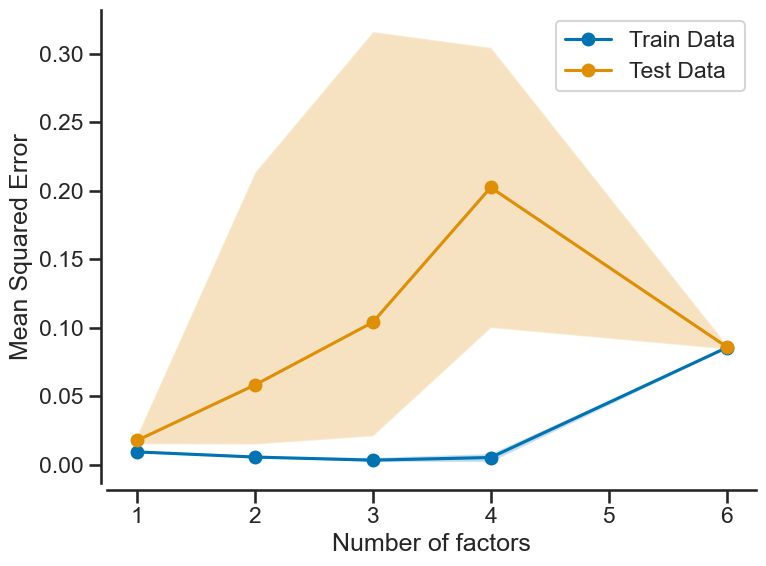

In [ ]:
from scipy.signal import argrelextrema

fig, ax = plt.subplots(1, figsize=(8, 6))

ax.plot(groups["MSE"]["mean"]["Train"], 'o-', label="Train Data")
ax.plot(groups["MSE"]["mean"]["Test"], 'o-', label="Test Data")

ax.fill_between(groups["MSE"]["5%"]["Train"].index, groups["MSE"]["5%"]["Train"],
                groups["MSE"]["95%"]["Train"], alpha=0.25)
ax.fill_between(groups["MSE"]["5%"]["Test"].index, groups["MSE"]["5%"]["Test"],
                groups["MSE"]["95%"]["Test"], alpha=0.25)

test_mse = groups["MSE"]["mean"]["Test"].values
ranks = groups["MSE"]["mean"]["Test"].index.values

local_min_idx = argrelextrema(test_mse, np.less)[0]

if len(local_min_idx) > 0:
    inflection = ranks[local_min_idx[0]]
    ax.axvline(inflection, color='k', dashes=[2, 2])

sns.despine(offset=5)
ax.set_ylabel("Mean Squared Error")
ax.set_xlabel("Number of factors")
ax.legend()
plt.tight_layout()

N_FACTORS = 4

#####